#  Analisis Dataset `ingredients_master_final` & `nutrition_cleaned`

---




##  Data Dictionary

### Dataset `ingredients_master_final`

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| `nama_id` | string | Nama bahan dapur dalam Bahasa Indonesia |
| `frekuensi` | integer | Jumlah kemunculan / tingkat penggunaan bahan dalam resep |
| `kategori` | string | Kategori bahan (bumbu, protein_hewani, sayuran, dll.) |
| `umur_kulkas` | integer | Estimasi umur simpan (hari) jika disimpan di kulkas (±4°C) |
| `umur_suhu_ruang` | integer | Estimasi umur simpan (hari) jika disimpan di suhu ruang (25–30°C) |
| `umur_freezer` | integer | Estimasi umur simpan (hari) jika disimpan di freezer (≤-18°C) |
| `kalori_per_100g` | float | Kandungan kalori per 100 gram bahan (kkal) |
| `protein_g` | float | Kandungan protein per 100 gram (gram) |
| `lemak_g` | float | Kandungan lemak per 100 gram (gram) |
| `karbo_g` | float | Kandungan karbohidrat per 100 gram (gram) |
| `karbon_co2e` | float | Estimasi emisi karbon per kg bahan (kg CO₂e)  |

### Dataset `nutrition_cleaned`

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| `nama_bersih` | string | Nama bahan dapur (versi bersih, lowercase) |
| `kalori_per_100g` | float | Kalori per 100 gram (kkal) |
| `protein_g` | float | Protein per 100 gram (gram) |
| `lemak_g` | float | Lemak per 100 gram (gram) |
| `karbo_g` | float | Karbohidrat per 100 gram (gram) |

---


##  Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi tampilan
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

print(" Library berhasil diimpor.")


 Library berhasil diimpor.


##  Load Dataset

In [5]:
df = pd.read_json('/content/ingredients_master_final (1).json')
cols_utama = ['nama_id', 'frekuensi', 'kategori', 'umur_kulkas', 'umur_suhu_ruang', 'umur_freezer']

df_nutrition = pd.read_csv('/content/nutrition_cleaned.csv')

print(f"Dataset Utama  : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Dataset Gizi   : {df_nutrition.shape[0]:,} baris × {df_nutrition.shape[1]} kolom")
print()
print("─── Preview Dataset Ingredients Master ───")
df[cols_utama].head()


Dataset Utama  : 1,560 baris × 11 kolom
Dataset Gizi   : 1,244 baris × 5 kolom

─── Preview Dataset Ingredients Master ───


,nama_id,frekuensi,kategori,umur_kulkas,umur_suhu_ruang,umur_freezer
0,bawang putih,707,bumbu,30,14,0
1,garam,590,bumbu,1825,1825,0
2,bawang merah,528,bumbu,30,14,0
3,air,321,bumbu,1,1,0
4,kecap,263,bumbu,365,180,0


##  Periksa Data

In [6]:
print("═" * 55)
print("  INFORMASI DATASET INGREDIENTS MASTER")
print("═" * 55)
df.info()
print()
print("─── Nilai Kosong per Kolom ───")
print(df[cols_utama].isnull().sum())
print()
print("─── Statistik Deskriptif (Kolom Utama) ───")
df[cols_utama].describe().round(2)


═══════════════════════════════════════════════════════
  INFORMASI DATASET INGREDIENTS MASTER
═══════════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nama_id          1560 non-null   object 
 1   frekuensi        1560 non-null   int64  
 2   kategori         1560 non-null   object 
 3   umur_kulkas      1560 non-null   int64  
 4   umur_suhu_ruang  1560 non-null   int64  
 5   umur_freezer     1560 non-null   int64  
 6   kalori_per_100g  1560 non-null   float64
 7   protein_g        1560 non-null   float64
 8   lemak_g          1560 non-null   float64
 9   karbo_g          1560 non-null   float64
 10  karbon_co2e      910 non-null    float64
dtypes: float64(5), int64(4), object(2)
memory usage: 134.2+ KB

─── Nilai Kosong per Kolom ───
nama_id            0
frekuensi          0
katego

,frekuensi,umur_kulkas,umur_suhu_ruang,umur_freezer
count,1560.00,1560.00,1560.00,1560.00
mean,6.50,145.76,110.50,33.08
std,34.53,328.18,318.33,43.00
min,1.00,1.00,0.00,0.00
25%,1.00,3.00,1.00,0.00
50%,1.00,7.00,2.00,0.00
75%,2.00,365.00,60.00,60.00
max,707.00,1825.00,1825.00,120.00


In [7]:
print("─── Distribusi Kategori Bahan ───")
print(df['kategori'].value_counts())
print()
print(f"Jumlah kategori unik : {df['kategori'].nunique()}")
print(f"Jumlah bahan unik    : {df['nama_id'].nunique():,}")


─── Distribusi Kategori Bahan ───
kategori
bumbu             430
protein_hewani    332
olahan            225
rempah            204
sayuran           130
karbohidrat       113
protein_nabati     80
buah               46
Name: count, dtype: int64

Jumlah kategori unik : 8
Jumlah bahan unik    : 1,560


---
##  Pertanyaan Bisnis 1
### Kategori bahan apa yang paling banyak digunakan dalam resep, dan seberapa besar kontribusinya terhadap total penggunaan?




In [8]:
# Agregasi total frekuensi per kategori
frekuensi_per_kategori = (
    df.groupby('kategori')['frekuensi']
    .agg(total_frekuensi='sum', jumlah_bahan='count', rata_frekuensi='mean')
    .sort_values('total_frekuensi', ascending=False)
    .reset_index()
)

total_semua = frekuensi_per_kategori['total_frekuensi'].sum()
frekuensi_per_kategori['persentase'] = (
    frekuensi_per_kategori['total_frekuensi'] / total_semua * 100
).round(2)

print(frekuensi_per_kategori.to_string(index=False))


      kategori  total_frekuensi  jumlah_bahan  rata_frekuensi  persentase
         bumbu             5249           430       12.206977       51.74
        rempah             2198           204       10.774510       21.67
protein_hewani              926           332        2.789157        9.13
       sayuran              606           130        4.661538        5.97
        olahan              421           225        1.871111        4.15
   karbohidrat              316           113        2.796460        3.12
protein_nabati              289            80        3.612500        2.85
          buah              139            46        3.021739        1.37


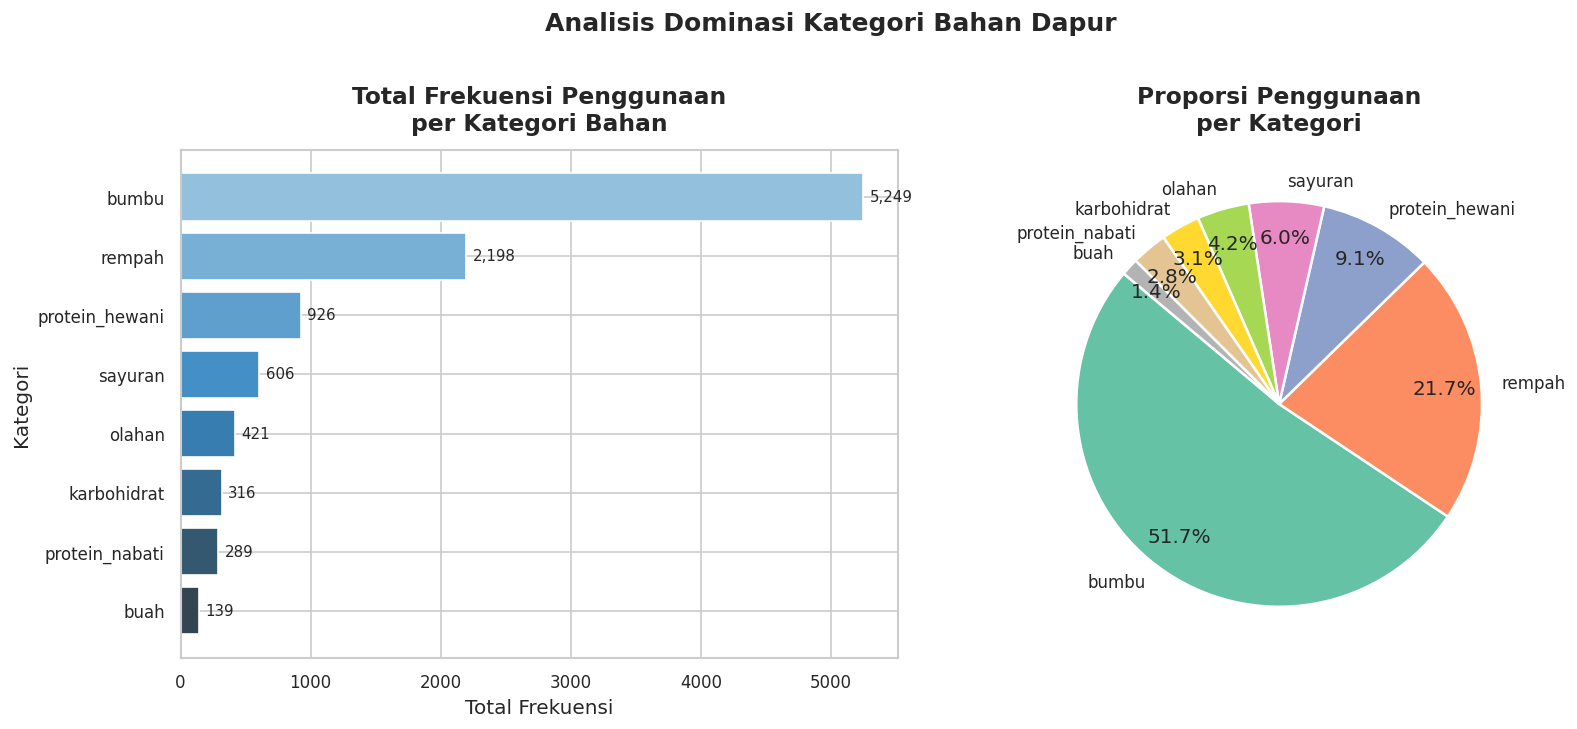

Grafik 1 tersimpan


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Bar chart
palette_bar = sns.color_palette('Blues_d', len(frekuensi_per_kategori))
bars = axes[0].barh(
    frekuensi_per_kategori['kategori'],
    frekuensi_per_kategori['total_frekuensi'],
    color=palette_bar
)
axes[0].set_title('Total Frekuensi Penggunaan\nper Kategori Bahan', pad=12)
axes[0].set_xlabel('Total Frekuensi')
axes[0].set_ylabel('Kategori')
axes[0].invert_yaxis()
for bar, val in zip(bars, frekuensi_per_kategori['total_frekuensi']):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)

# Subplot 2: Pie chart
wedge_props = {'linewidth': 1.5, 'edgecolor': 'white'}
axes[1].pie(
    frekuensi_per_kategori['total_frekuensi'],
    labels=frekuensi_per_kategori['kategori'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(frekuensi_per_kategori)),
    wedgeprops=wedge_props,
    pctdistance=0.82
)
axes[1].set_title('Proporsi Penggunaan\nper Kategori', pad=12)

plt.suptitle('Analisis Dominasi Kategori Bahan Dapur', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_1_kategori_frekuensi.png', bbox_inches='tight')
plt.show()
print("Grafik 1 tersimpan")


---
## Pertanyaan Bisnis 2
### Bahan-bahan apa saja yang paling sering digunakan (top 20), dan apakah ketersediaannya sudah mencerminkan prioritas stok yang tepat?



In [10]:
# Top 20 bahan berdasarkan frekuensi
top20 = (
    df[cols_utama]
    .sort_values('frekuensi', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20.index += 1
print(top20[['nama_id', 'frekuensi', 'kategori']].to_string())


          nama_id  frekuensi kategori
1    bawang putih        707    bumbu
2           garam        590    bumbu
3    bawang merah        528    bumbu
4             air        321    bumbu
5           kecap        263    bumbu
6          minyak        239    bumbu
7            gula        211    bumbu
8            jahe        204   rempah
9     daun bawang        186    bumbu
10          tomat        183  sayuran
11     daun salam        181   rempah
12     daun jeruk        173   rempah
13  bawang bombai        167    bumbu
14         kunyit        164   rempah
15          serai        155   rempah
16         kemiri        153   rempah
17       lengkuas        151   rempah
18       ketumbar        146   rempah
19           lada        140   rempah
20     cabe merah        137    bumbu


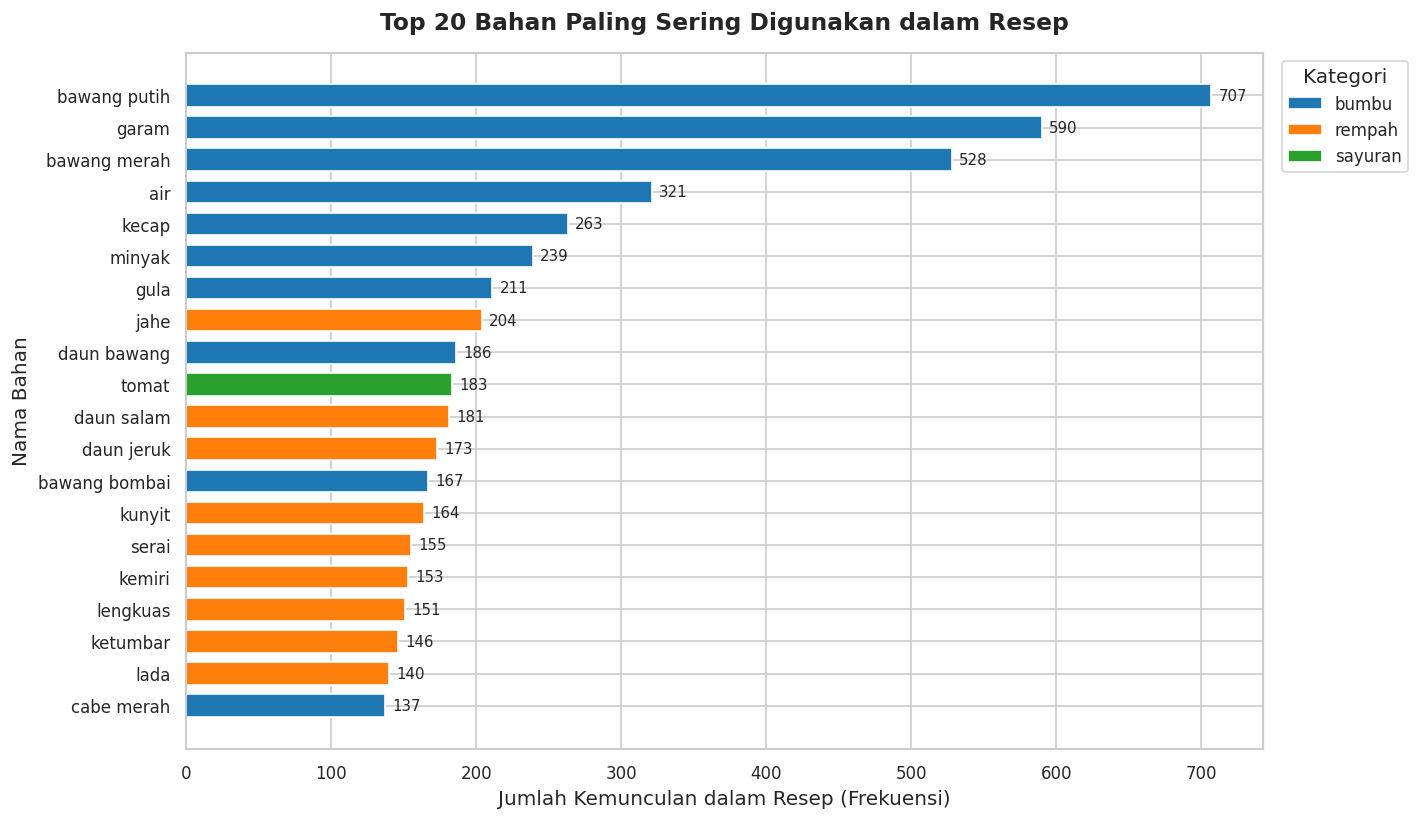

Grafik 2 tersimpan.


In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

kategori_unik = top20['kategori'].unique()
color_map = dict(zip(kategori_unik, sns.color_palette('tab10', len(kategori_unik))))
colors = top20['kategori'].map(color_map)

bars = ax.barh(top20['nama_id'], top20['frekuensi'], color=colors, edgecolor='white', height=0.7)
ax.invert_yaxis()
ax.set_title('Top 20 Bahan Paling Sering Digunakan dalam Resep', pad=14)
ax.set_xlabel('Jumlah Kemunculan dalam Resep (Frekuensi)')
ax.set_ylabel('Nama Bahan')

for bar, val in zip(bars, top20['frekuensi']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

# Legenda kategori
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[k], label=k) for k in kategori_unik]
ax.legend(handles=legend_elements, title='Kategori', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('viz_2_top20_bahan.png', bbox_inches='tight')
plt.show()
print("Grafik 2 tersimpan.")


---
## Pertanyaan Bisnis 3
### Bagaimana perbandingan rata-rata umur simpan bahan di kulkas, suhu ruang, dan freezer antar kategori? Kategori mana yang paling rentan pembusukan?




In [12]:
# Rata-rata umur simpan per kategori
umur_per_kategori = (
    df.groupby('kategori')[['umur_kulkas', 'umur_suhu_ruang', 'umur_freezer']]
    .mean()
    .round(1)
    .sort_values('umur_suhu_ruang', ascending=True)
    .reset_index()
)

print("Rata-rata Umur Simpan (hari) per Kategori:")
print(umur_per_kategori.to_string(index=False))


Rata-rata Umur Simpan (hari) per Kategori:
      kategori  umur_kulkas  umur_suhu_ruang  umur_freezer
protein_hewani          3.9              0.4          97.5
        olahan         12.8              2.5          24.9
       sayuran          7.8              2.7          25.6
protein_nabati         25.5              9.4          21.8
          buah         34.2             14.4           3.3
        rempah        232.3            169.9          18.7
   karbohidrat        280.7            230.2           5.3
         bumbu        324.4            254.1           9.3


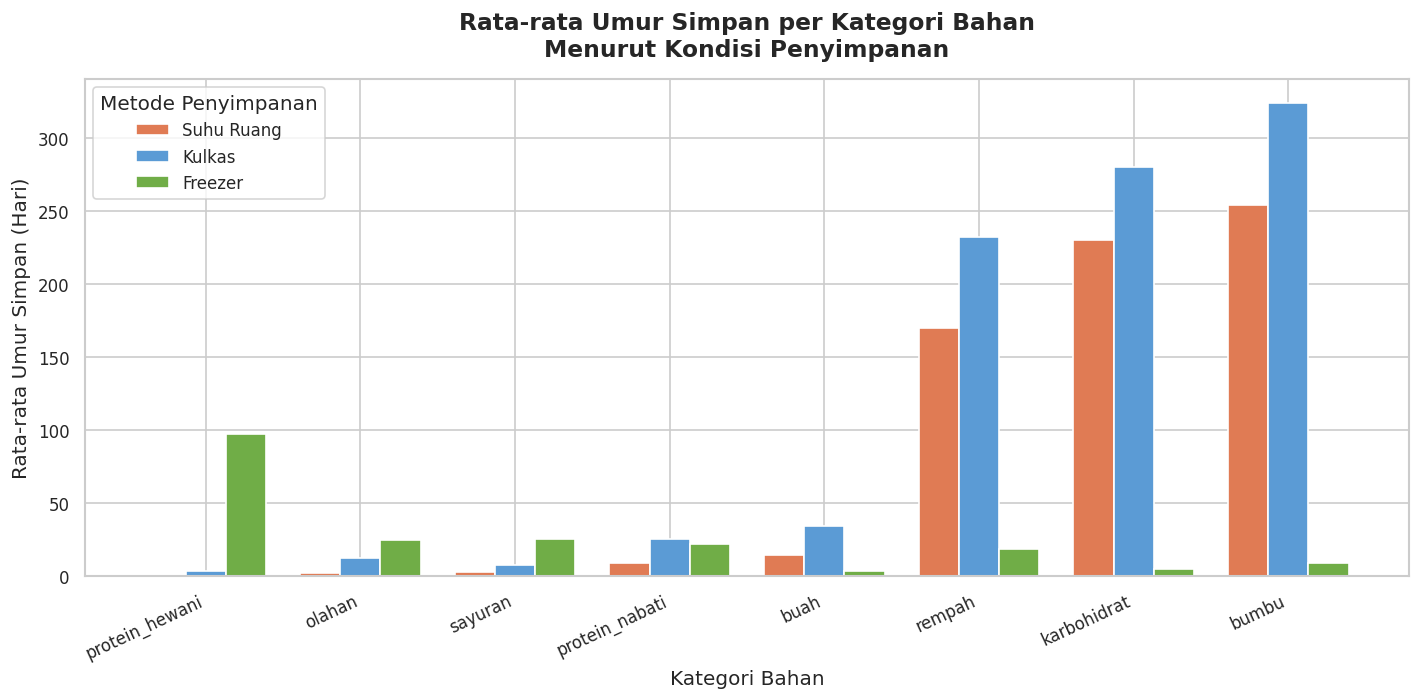

 Grafik 3 tersimpan


In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(umur_per_kategori))
width = 0.26

bar1 = ax.bar(x - width, umur_per_kategori['umur_suhu_ruang'], width,
              label='Suhu Ruang', color='#e07b54', edgecolor='white')
bar2 = ax.bar(x,          umur_per_kategori['umur_kulkas'],      width,
              label='Kulkas',      color='#5b9bd5', edgecolor='white')
bar3 = ax.bar(x + width, umur_per_kategori['umur_freezer'],      width,
              label='Freezer',     color='#70ad47', edgecolor='white')

ax.set_title('Rata-rata Umur Simpan per Kategori Bahan\nMenurut Kondisi Penyimpanan', pad=14)
ax.set_xlabel('Kategori Bahan')
ax.set_ylabel('Rata-rata Umur Simpan (Hari)')
ax.set_xticks(x)
ax.set_xticklabels(umur_per_kategori['kategori'], rotation=25, ha='right')
ax.legend(title='Metode Penyimpanan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{int(val):,}'))

plt.tight_layout()
plt.savefig('viz_3_umur_simpan_kategori.png', bbox_inches='tight')
plt.show()
print(" Grafik 3 tersimpan")


---
## Pertanyaan Bisnis 4
### Berapa proporsi bahan yang tergolong "berisiko tinggi" pembusukan (umur simpan suhu ruang ≤ 3 hari), dan tersebar di kategori apa saja?



In [14]:
# Klasifikasi risiko pembusukan
def klasifikasi_risiko(hari):
    if hari <= 3:
        return 'Tinggi (≤3 hari)'
    elif hari <= 7:
        return 'Sedang (4–7 hari)'
    else:
        return 'Rendah (>7 hari)'

df['risiko_suhu_ruang'] = df['umur_suhu_ruang'].apply(klasifikasi_risiko)

ringkasan_risiko = df['risiko_suhu_ruang'].value_counts()
print("Distribusi Risiko Pembusukan di Suhu Ruang:")
print(ringkasan_risiko)
print()

# Breakdown per kategori
risiko_kategori = (
    df[df['risiko_suhu_ruang'] == 'Tinggi (≤3 hari)']
    .groupby('kategori')['nama_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'nama_id': 'jumlah_bahan_berisiko'})
)
print("Bahan Berisiko Tinggi per Kategori:")
print(risiko_kategori.to_string(index=False))


Distribusi Risiko Pembusukan di Suhu Ruang:
risiko_suhu_ruang
Tinggi (≤3 hari)     917
Rendah (>7 hari)     509
Sedang (4–7 hari)    134
Name: count, dtype: int64

Bahan Berisiko Tinggi per Kategori:
      kategori  jumlah_bahan_berisiko
protein_hewani                    312
        olahan                    189
         bumbu                    154
       sayuran                    115
protein_nabati                     66
          buah                     41
        rempah                     22
   karbohidrat                     18


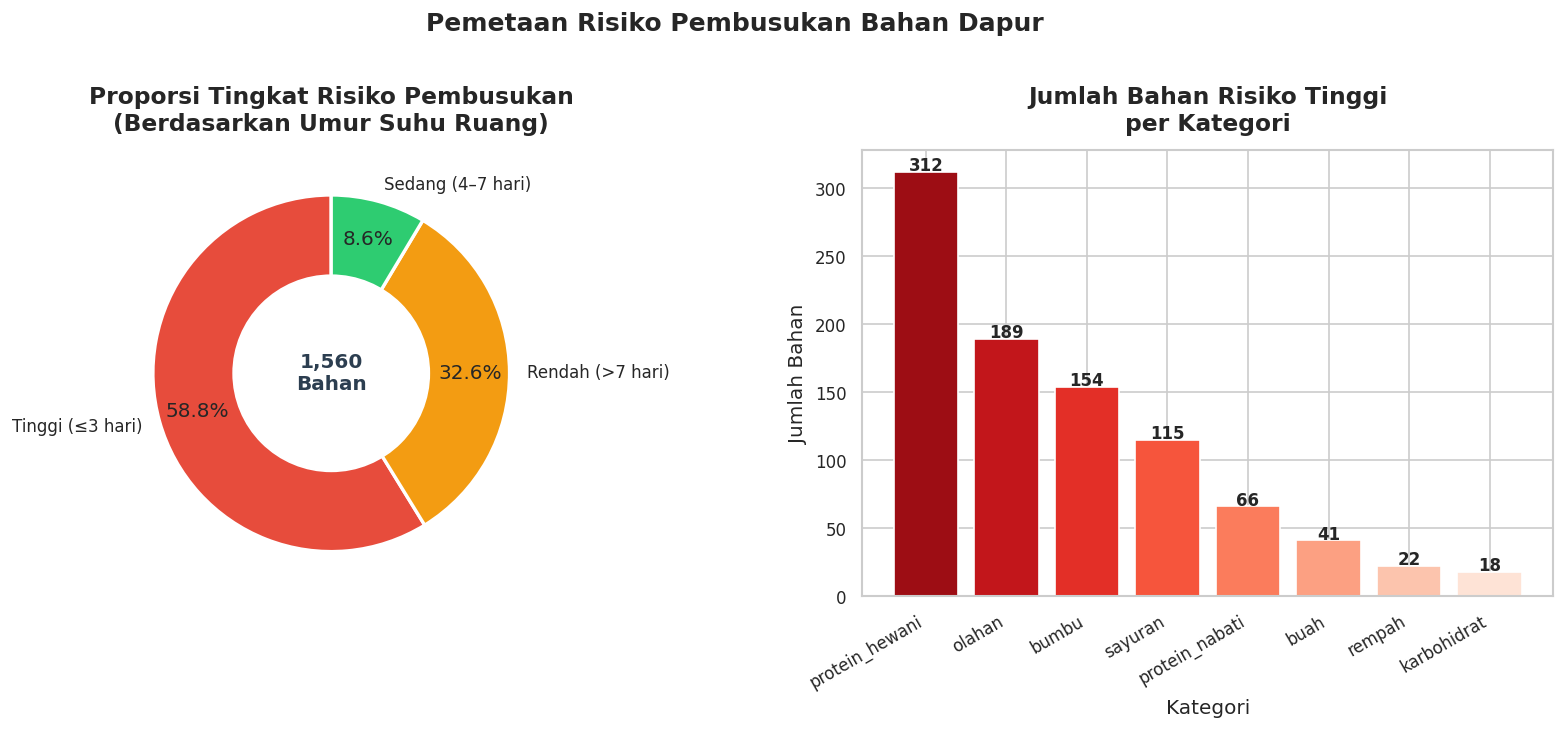

Grafik 4 tersimpan.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Donut chart risiko
risiko_labels = ringkasan_risiko.index
risiko_values = ringkasan_risiko.values
risiko_colors = ['#e74c3c', '#f39c12', '#2ecc71']
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}

wedges, texts, autotexts = axes[0].pie(
    risiko_values, labels=risiko_labels, autopct='%1.1f%%',
    colors=risiko_colors, wedgeprops=wedge_props, startangle=90,
    pctdistance=0.78
)
# Buat lubang donut
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[0].add_artist(centre_circle)
total_bahan = sum(risiko_values)
axes[0].text(0, 0, f'{total_bahan:,}\nBahan', ha='center', va='center',
             fontsize=12, fontweight='bold', color='#2c3e50')
axes[0].set_title('Proporsi Tingkat Risiko Pembusukan\n(Berdasarkan Umur Suhu Ruang)', pad=12)

# Subplot 2: Bar chart per kategori
bar_colors = sns.color_palette('Reds_r', len(risiko_kategori))
axes[1].bar(risiko_kategori['kategori'], risiko_kategori['jumlah_bahan_berisiko'],
            color=bar_colors, edgecolor='white')
axes[1].set_title('Jumlah Bahan Risiko Tinggi\nper Kategori', pad=12)
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah Bahan')
axes[1].set_xticklabels(risiko_kategori['kategori'], rotation=30, ha='right')
for i, (_, row) in enumerate(risiko_kategori.iterrows()):
    axes[1].text(i, row['jumlah_bahan_berisiko'] + 1, str(row['jumlah_bahan_berisiko']),
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Pemetaan Risiko Pembusukan Bahan Dapur', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_4_risiko_pembusukan.png', bbox_inches='tight')
plt.show()
print("Grafik 4 tersimpan.")


---
## Pertanyaan Bisnis 5
### Bahan apa saja yang paling hemat kalori namun tinggi protein (efisiensi nutrisi tertinggi), dan kategori apa yang mendominasi?


In [16]:
# ── Perhitungan Efisiensi Nutrisi ──────────────────────────────────────
# Efisiensi = protein_g / kalori_per_100g × 100  (gram protein per 100 kkal)
# Hanya bahan yang memiliki data kalori > 0 dan protein > 0

df_gizi = df[
    (df['kalori_per_100g'] > 0) &
    (df['protein_g'] > 0)
].copy()

df_gizi['efisiensi_nutrisi'] = (df_gizi['protein_g'] / df_gizi['kalori_per_100g'] * 100).round(2)

# Klasifikasi efisiensi
def label_efisiensi(val):
    if val >= 10:
        return 'Sangat Tinggi (≥10)'
    elif val >= 5:
        return 'Tinggi (5–10)'
    elif val >= 2:
        return 'Sedang (2–5)'
    else:
        return 'Rendah (<2)'

df_gizi['kelas_efisiensi'] = df_gizi['efisiensi_nutrisi'].apply(label_efisiensi)

# Top 15 bahan paling efisien
top15_efisien = (
    df_gizi
    .sort_values('efisiensi_nutrisi', ascending=False)
    .head(15)
    [['nama_id', 'kategori', 'kalori_per_100g', 'protein_g', 'efisiensi_nutrisi']]
    .reset_index(drop=True)
)
top15_efisien.index += 1

# Distribusi kelas efisiensi
dist_kelas = df_gizi['kelas_efisiensi'].value_counts().reindex(
    ['Sangat Tinggi (≥10)', 'Tinggi (5–10)', 'Sedang (2–5)', 'Rendah (<2)']
).fillna(0).astype(int)

# Rata-rata efisiensi per kategori
eff_per_kategori = (
    df_gizi.groupby('kategori')['efisiensi_nutrisi']
    .agg(rata2='mean', jumlah='count')
    .round(2)
    .sort_values('rata2', ascending=False)
    .reset_index()
)

print("TOP 15 BAHAN DENGAN EFISIENSI NUTRISI TERTINGGI")
print("(Gram Protein per 100 kkal)")
print()
print(top15_efisien.to_string())
print()
print("DISTRIBUSI KELAS EFISIENSI NUTRISI")
for kls, cnt in dist_kelas.items():
    pct = cnt / len(df_gizi) * 100
    print(f"  {kls:25} : {cnt:>4} bahan  ({pct:.1f}%)")
print()
print(f"Total bahan dengan data gizi lengkap : {len(df_gizi)}")
print(f"Rata-rata efisiensi nutrisi keseluruhan: {df_gizi['efisiensi_nutrisi'].mean():.2f} g protein / 100 kkal")


TOP 15 BAHAN DENGAN EFISIENSI NUTRISI TERTINGGI
(Gram Protein per 100 kkal)

              nama_id        kategori  kalori_per_100g  protein_g  efisiensi_nutrisi
1        ragi instant           bumbu            136.0       43.0              31.62
2         ragi instan           bumbu            136.0       43.0              31.62
3        kakap fillet  protein_hewani             92.0       20.0              21.74
4         kakap merah  protein_hewani             92.0       20.0              21.74
5   kepala ikan kakap  protein_hewani             92.0       20.0              21.74
6    ikan kembung sdh  protein_hewani            103.0       22.0              21.36
7        ikan kembung  protein_hewani            103.0       22.0              21.36
8        tepung kanji     karbohidrat            316.0       60.1              19.02
9   daging sapi bagus  protein_hewani            182.0       32.0              17.58
10       ikan bandeng  protein_hewani            129.0       20.0        

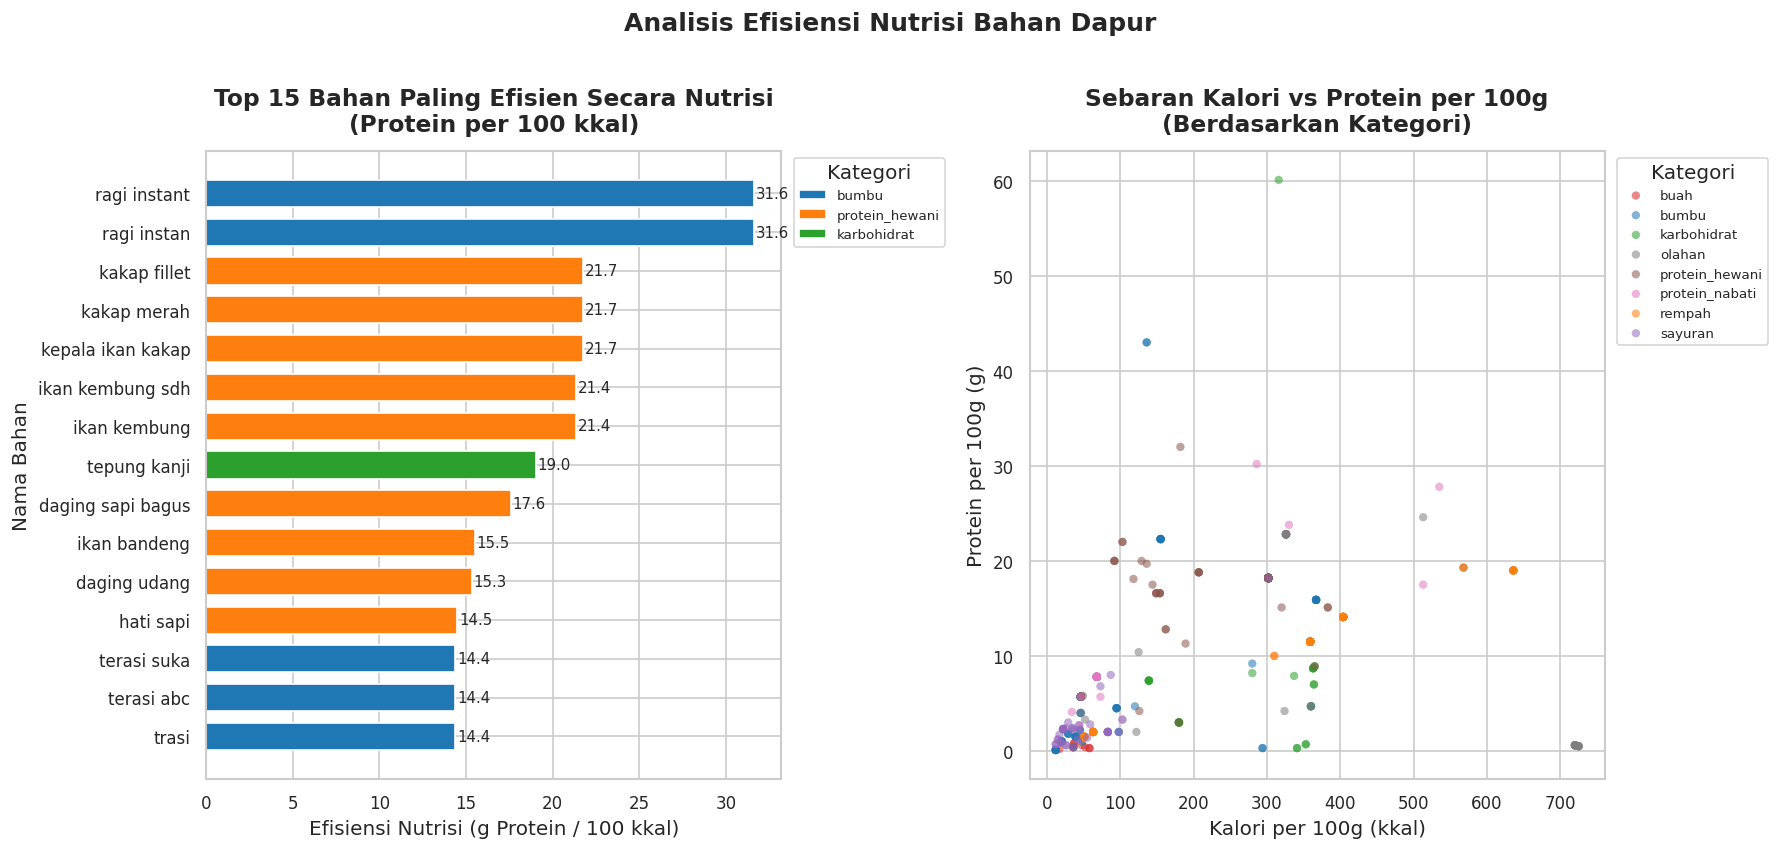

Grafik 5 tersimpan.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ── Subplot 1: Horizontal Bar — Top 15 Efisiensi Nutrisi ──────────────
kategori_unik_eff = top15_efisien['kategori'].unique()
color_map_eff = dict(zip(kategori_unik_eff, sns.color_palette('tab10', len(kategori_unik_eff))))
bar_colors = top15_efisien['kategori'].map(color_map_eff)

bars = axes[0].barh(
    top15_efisien['nama_id'],
    top15_efisien['efisiensi_nutrisi'],
    color=bar_colors,
    edgecolor='white',
    height=0.7
)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Bahan Paling Efisien Secara Nutrisi\n(Protein per 100 kkal)', pad=12)
axes[0].set_xlabel('Efisiensi Nutrisi (g Protein / 100 kkal)')
axes[0].set_ylabel('Nama Bahan')

for bar, val in zip(bars, top15_efisien['efisiensi_nutrisi']):
    axes[0].text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}',
        va='center', fontsize=9
    )

from matplotlib.patches import Patch
legend_eff = [Patch(facecolor=color_map_eff[k], label=k) for k in kategori_unik_eff]
axes[0].legend(handles=legend_eff, title='Kategori', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# ── Subplot 2: Scatter — Kalori vs Protein, warna per kategori ────────
all_cats = df_gizi['kategori'].unique()
cat_colors = dict(zip(all_cats, sns.color_palette('tab10', len(all_cats))))

for cat, grp in df_gizi.groupby('kategori'):
    axes[1].scatter(
        grp['kalori_per_100g'], grp['protein_g'],
        label=cat, color=cat_colors[cat],
        alpha=0.55, s=25, edgecolors='none'
    )

axes[1].set_title('Sebaran Kalori vs Protein per 100g\n(Berdasarkan Kategori)', pad=12)
axes[1].set_xlabel('Kalori per 100g (kkal)')
axes[1].set_ylabel('Protein per 100g (g)')
axes[1].legend(title='Kategori', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.suptitle('Analisis Efisiensi Nutrisi Bahan Dapur', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_5_efisiensi_nutrisi.png', bbox_inches='tight')
plt.show()
print("Grafik 5 tersimpan.")


---
##  Kesimpulan & Rekomendasi

### Kesimpulan

**1. Bumbu mendominasi pemakaian di dapur.** Kategori bumbu muncul sebanyak 5.249 kali (51,7% dari total data), jauh di atas kategori lainnya. Hal ini menunjukkan bahwa operasional masakan sangat bergantung pada ketersediaan bumbu dasar dibandingkan bahan lainnya.

**2. Tiga bahan utama penyangga resep.** Bawang putih (707 kali), garam (590), dan bawang merah (528) adalah bahan yang paling sering dipakai. Kehabisan salah satu dari tiga bahan ini dipastikan akan menghambat proses masak secara keseluruhan.

**3. Protein hewani paling cepat busuk di suhu ruang.** Rata-rata daya simpan daging dan ikan di suhu ruang hampir nol hari. Namun, penyimpanannya bisa diselamatkan dan diperpanjang hingga sekitar 100 hari jika langsung dimasukkan ke dalam *freezer*.

**4. Lebih dari separuh bahan berisiko tinggi membusuk.** Sebanyak 58,8% dari total bahan (terutama dari kelompok protein hewani dan olahan) hanya mampu bertahan maksimal 3 hari di luar kulkas. Artinya, sebagian besar stok tidak bisa dibiarkan tergeletak di suhu ruang.

**5. Protein hewani adalah sumber gizi paling efisien.** Bahan seperti ikan kakap, ikan kembung, dan daging sapi memberikan rasio protein yang tinggi per kalori. Sementara itu, bumbu dan rempah murni hanya berfungsi sebagai perasa dan tidak menyumbang nutrisi makro secara signifikan.

---

###  Rekomendasi (Action Items)

**1. Terapkan belanja berkala (*Just-in-Time*) untuk bahan basah.** Karena 58,8% bahan sangat mudah rusak, hindari menyetok lauk pauk dan sayuran segar dalam jumlah besar untuk sebulan. Lakukan pemesanan setiap beberapa hari sekali untuk mencegah bahan terbuang (*food waste*).

**2. Maksimalkan kapasitas *freezer* khusus untuk lauk hewani.** Mengingat protein hewani paling cepat busuk di luar namun awet di suhu beku, prioritaskan ruang *freezer* untuk langsung menyimpan stok daging atau ikan mentah segera setelah barang datang dari *supplier*.

**3. Buat batas minimum (*safety stock*) untuk bawang dan garam.** Tiga bahan ini wajib selalu ada. Manajemen dapur harus menetapkan batas stok minimal, agar staf sudah memesan lagi sebelum stoknya benar-benar habis di dapur.

**4. Manfaatkan ikan untuk variasi menu sehat.** Melihat tingginya protein pada ikan kakap dan kembung dengan kalori yang efisien, bahan ini bisa dikembangkan menjadi menu andalan bagi pelanggan atau target pasar yang peduli pada kesehatan dan diet.

**5. Evaluasi ulang bahan yang jarang dipakai tapi mudah rusak.** Jika ada bahan yang frekuensi pemakaiannya sangat rendah (jarang ada di resep) tetapi cepat membusuk, pertimbangkan untuk menggantinya dengan alternatif bahan bubuk/kering yang fungsinya mirip agar lebih awet.